#### [ 와인 분류 ]

- 데이터셋: wine_quality_merged.csv 
  * 샘플 수: 6497개
  * 특성:  
  * 타겟: 
- 학습종류: 특성 + 타겟 구조 → 지도학습 => 로지스틱 회귀분석
- 알고리즘: 
- 전처리: 
- 평가지표: 정확도, 정밀도, 재현율, F1-Score
- 성공기준: 

In [69]:
# 데이터 불균형 처리
# red/white 비율이 크게 차이 난다면, class_weight='balanced' 옵션을 LogisticRegression에 추가해 보세요.
# 피처 선택
# penalty='l1' (Lasso 규제) 사용 시 자동으로 중요하지 않은 피처의 계수를 0으로 만들어줍니다 → 변수 선택 효과.
# 성능 지표 선택
# 클래스가 균형적이면 Accuracy & ROC-AUC 위주로,
# 불균형이면 Precision, Recall, F1도 꼭 같이 확인하세요.
# 임계값 조정
# predict_proba 결과를 이용해 임계값(threshold) 을 바꾸면 Precision-Recall trade-off를 조정할 수 있습니다.
# 해석하기
# 계수(coef) 부호:
# + → white(1) 쪽으로 확률 ↑
# − → red(0) 쪽으로 확률 ↑
# 크기: 영향력의 세기 (표준화된 입력을 쓰므로 비교 가능)

In [70]:
# 클래스가 균형(white ≈ red)
# 정확도 + ROC-AUC 위주로 봐도 충분
# 정확도: 전체 분류 성능
# ROC-AUC: 확률 모델의 분리 능력

# 클래스가 불균형 (예: white 80%, red 20%)
# 정확도만 보면 착시가 생김 → 반드시 정밀도·재현율·F1 같이 확인
# 특히 적은 쪽 클래스(소수 클래스)가 중요한 경우, Recall이나 F1 위주
# 의사결정 문제에 따라
# 위양성(False Positive) 비용이 크면 → Precision
# 위음성(False Negative) 비용이 크면 → Recall

# 두 개 다 중요하면 → F1

# 기본적으로는 정확도 + ROC-AUC
# 불균형 데이터라면 → 정밀도, 재현율, F1 꼭 확인

[1] 모듈 로딩 및 데이터 준비 <hr>
 - 데이터 로딩
 - 기본 정보 확인

In [71]:
## [1-1] 모듈 로딩
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [72]:
## [1-2] 데이터 기본 정보 확인
## 데이터 로딩
DATA_FILE = '../Data/wine_quality_merged.csv'

## 피쳐/타겟/클래스
wineDF = pd.read_csv(DATA_FILE, encoding='utf8')

## 데이터 기본 정보
print(f' wineDF.dtypes : {wineDF.dtypes}')

 wineDF.dtypes : fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                     object
dtype: object


In [73]:
## [1-3] 결측치 확인
print("\n[결측치 수]\n", wineDF.isnull().sum())
print("\n[type 분포]\n", wineDF["type"].value_counts(dropna=False)) # red/white 분포


[결측치 수]
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

[type 분포]
 type
white    4898
red      1599
Name: count, dtype: int64


[2] 탐색적 데이터 분석 <hr>

In [74]:
# [2-1] 기초 통계와 타겟별 평균
display(wineDF.describe())

num_cols = [c for c in wineDF.columns if wineDF[c].dtype != 'O' and c not in ['type_bin']]
group_mean = wineDF.groupby('type')[num_cols].mean()
display(group_mean)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
type,,,,,,,,,,,,
red,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
white,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909


In [75]:
## 타겟('type')별 데이터 개수 확인
print(wineDF['type'].value_counts())

## 중복데이터 확인 및 제거
print(wineDF.duplicated(subset=list(wineDF.columns)).sum())
wineDF = wineDF.drop_duplicates(keep='first')
print(wineDF.duplicated(subset=list(wineDF.columns)).sum())

## 중복데이터 제거 후 데이터 확인
print(wineDF['type'].value_counts())

type
white    4898
red      1599
Name: count, dtype: int64
1177
0
type
white    3961
red      1359
Name: count, dtype: int64


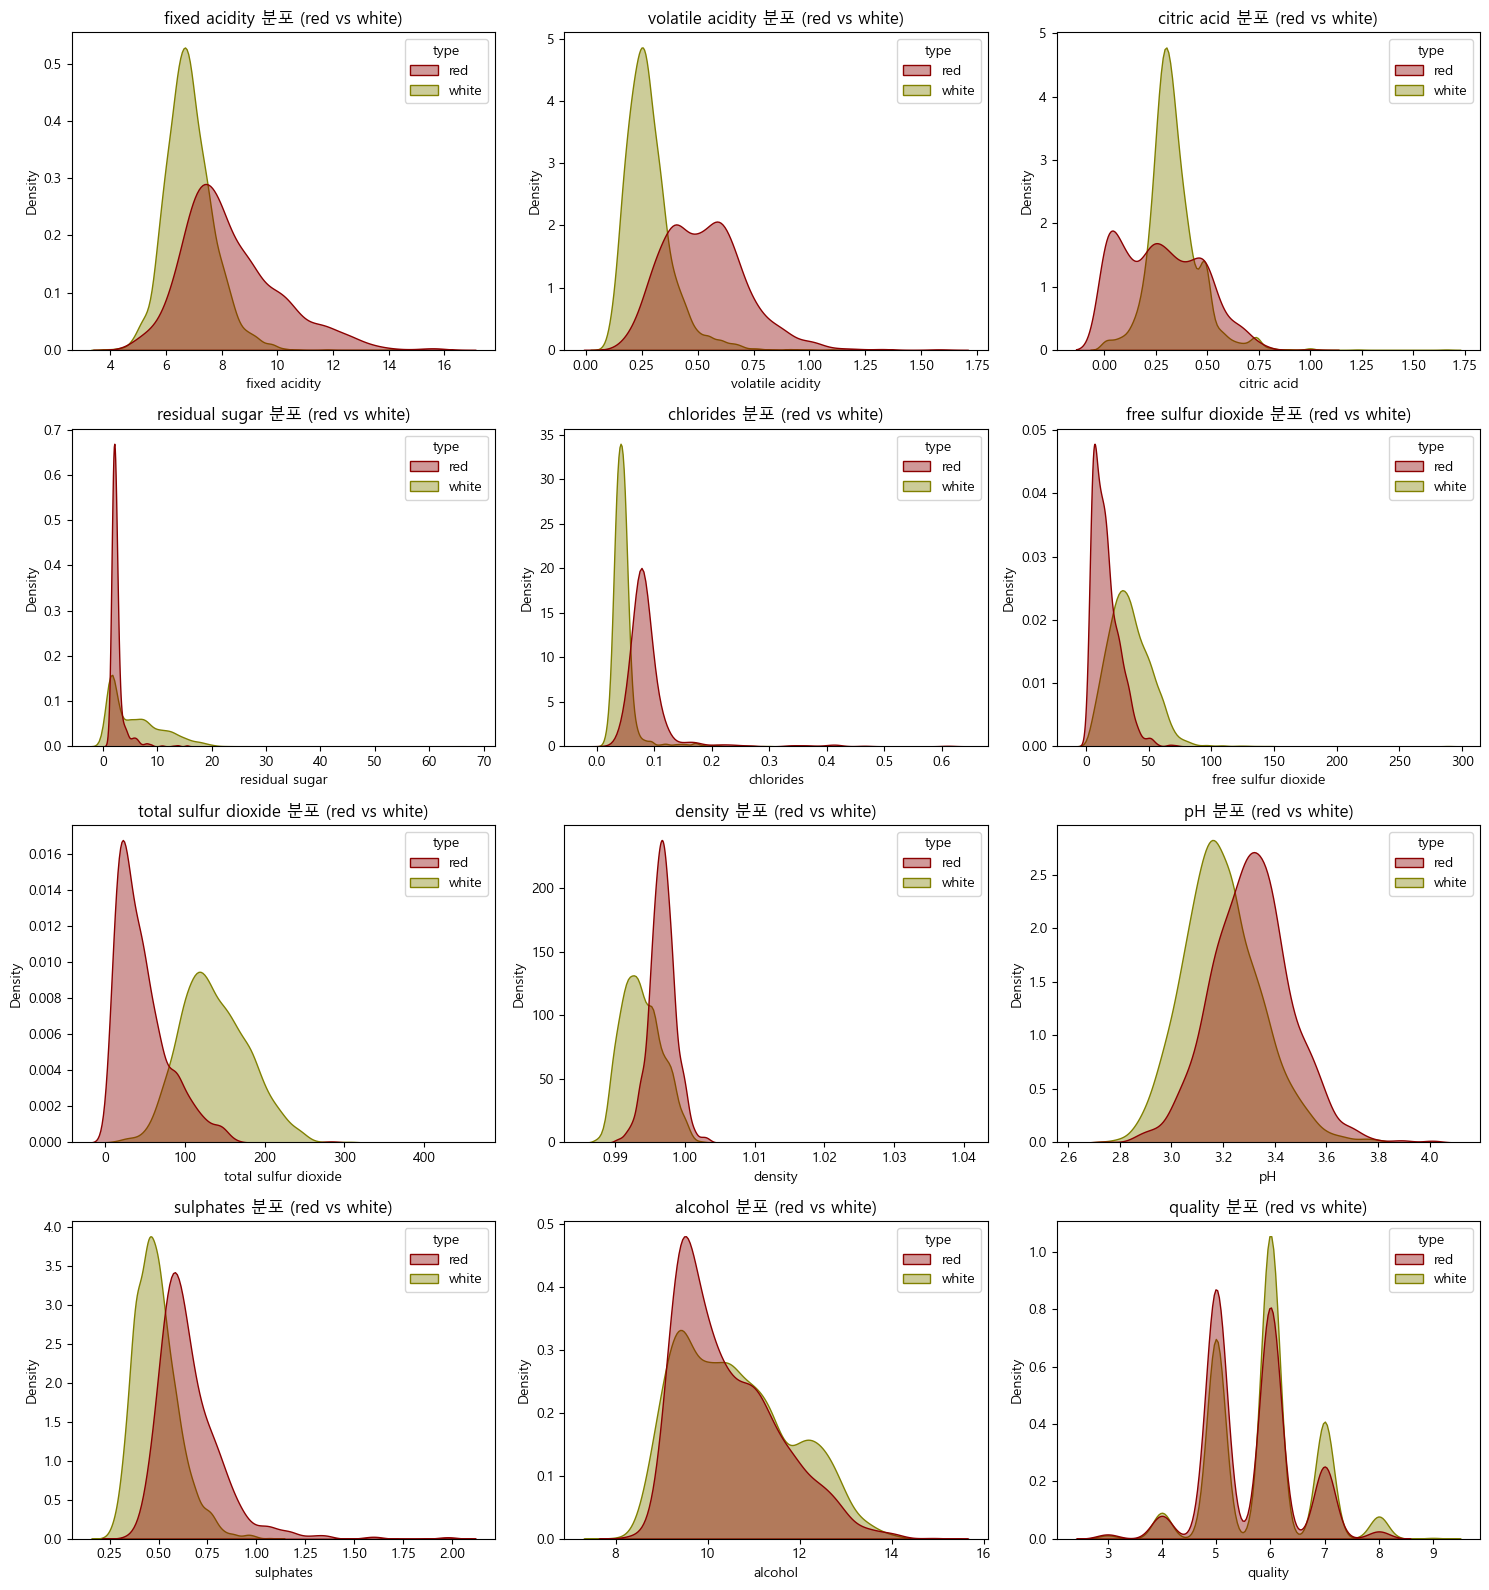

In [76]:
# [2-2] 각 피처 분포 (red vs white)
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rc('font', family='Malgun Gothic')  # Windows: 맑은 고딕
mpl.rcParams['axes.unicode_minus'] = False

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
plt.figure(figsize=(15, 4*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(data=wineDF, x=col, hue='type', fill=True, common_norm=False, alpha=0.4, palette=['darkred', 'olive'])
    plt.title(f"{col} 분포 (red vs white)")

plt.tight_layout()
plt.show()


In [77]:
## [2-2] 피쳐/타겟 분류
featureDF = wineDF.drop(['type'], axis=1)
targetSR = wineDF['type'].map({'red':0, 'white':1})

print(f'[FEATUE] : {featureDF.columns}')
print(f'[TARGET] : {targetSR.value_counts}')

[FEATUE] : Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
[TARGET] : <bound method IndexOpsMixin.value_counts of 0       0
1       0
2       0
3       0
5       0
       ..
6492    1
6493    1
6494    1
6495    1
6496    1
Name: type, Length: 5320, dtype: int64>


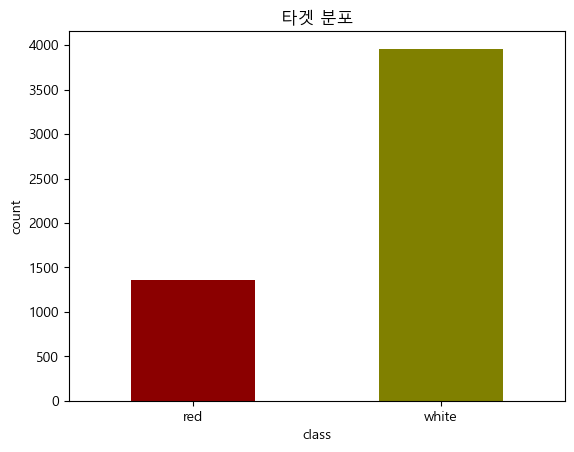

In [78]:
## [2-3] 클래스 분포 확인(불균형 여부)
## [2-3] 클래스 분포 확인(불균형 여부)
ax = targetSR.value_counts().sort_index().rename({0:'red', 1:'white'}).plot(kind='bar', 
                                                                            color=['darkred', 'olive'])
plt.title('타겟 분포')
plt.xlabel('class')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.show()

In [79]:
## [2-4] 수치화된 상관관계
## 상관계수 |corr| 클수록 분류에 영향력 클 가능성
from scipy.stats import pointbiserialr
import pandas as pd

corr_list = []
for col in featureDF.columns :
    corr, p = pointbiserialr(targetSR, featureDF[col])
    corr_list.append((col, corr, p))

corr_df = pd.DataFrame(corr_list, columns=['feature','corr','p_value'])
print(corr_df.sort_values('corr', ascending=False))


                 feature      corr        p_value
6   total sulfur dioxide  0.694229   0.000000e+00
5    free sulfur dioxide  0.465326  3.792741e-284
3         residual sugar  0.328695  3.086586e-134
2            citric acid  0.183759   1.272721e-41
11               quality  0.114809   4.472191e-17
10               alcohol  0.057756   2.495934e-05
8                     pH -0.310919  1.381789e-119
7                density -0.429377  1.185189e-237
0          fixed acidity -0.486253  6.745890e-314
9              sulphates -0.490364  5.462390e-320
4              chlorides -0.499517   0.000000e+00
1       volatile acidity -0.645335   0.000000e+00


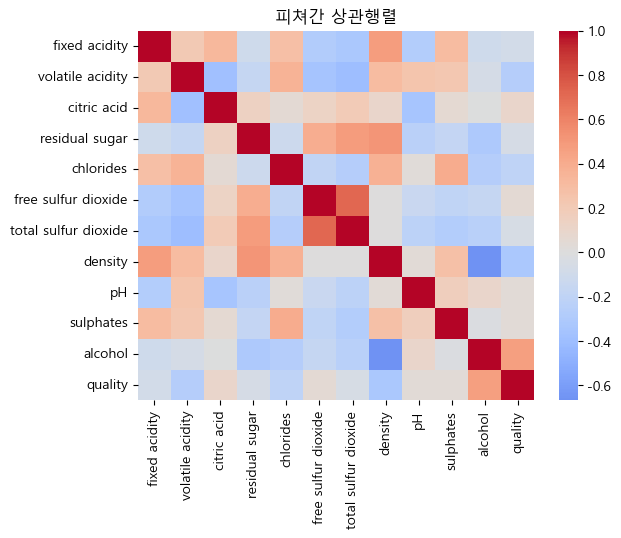

In [80]:
## [2-5] 다중공선성 점검(피쳐 간 상관)
plt.Figure(figsize=(10, 8))
sns.heatmap(featureDF.corr(), cmap='coolwarm', center=0)
plt.title('피쳐간 상관행렬')
plt.show()

                 feature        VIF
7                density  14.974456
3         residual sugar   6.481531
0          fixed acidity   4.894799
10               alcohol   4.764894
6   total sulfur dioxide   2.971476
8                     pH   2.495732
5    free sulfur dioxide   2.164336
1       volatile acidity   2.032674
2            citric acid   1.654919
4              chlorides   1.633497


C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_27240\3734398308.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="VIF", y="feature", data=vif_df, palette="viridis")


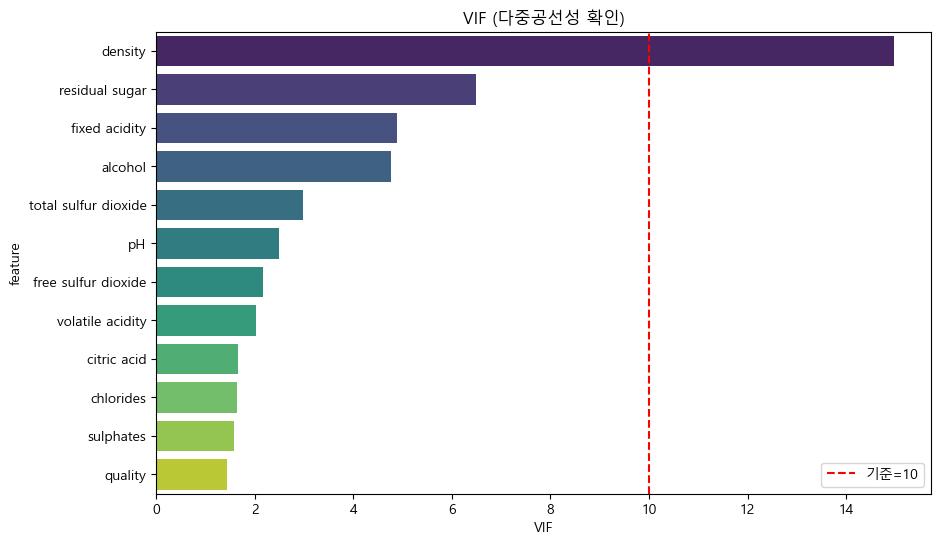

In [81]:
## [2-7] VIF(분산팽창계수) 다중공선성 정량 확인
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

X_vif = featureDF[num_cols].copy()
X_vif = (X_vif - X_vif.mean())/X_vif.std(ddof=0)  # 스케일링 후 VIF 계산 권장
vifs = []
for i, c in enumerate(num_cols):
    vifs.append((c, variance_inflation_factor(X_vif.values, i)))
vif_df = pd.DataFrame(vifs, columns=['feature','VIF']).sort_values('VIF', ascending=False)
print(vif_df.head(10))

## 시각화
plt.figure(figsize=(10,6))
sns.barplot(x="VIF", y="feature", data=vif_df, palette="viridis")
plt.axvline(10, color="r", linestyle="--", label="기준=10")
plt.title("VIF (다중공선성 확인)")
plt.legend()
plt.show()


                 feature     VIF_raw  VIF_scaled
7                density  939.742393   14.974456
8                     pH  589.056536    2.495732
10               alcohol  129.492727    4.764894
11               quality   63.889981    1.444099
0          fixed acidity   57.504809    4.894799
9              sulphates   18.761523    1.574175
6   total sulfur dioxide   14.357850    2.971476
2            citric acid    9.405483    1.654919
1       volatile acidity    9.337244    2.032674
5    free sulfur dioxide    8.323452    2.164336
4              chlorides    5.306619    1.633497
3         residual sugar    3.340998    6.481531


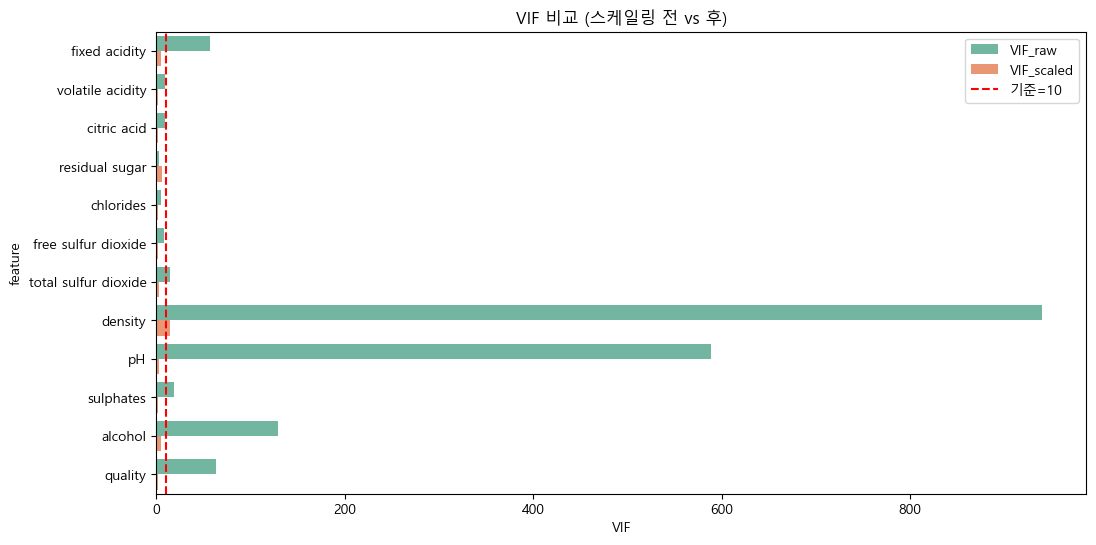

In [82]:
## VIF 비교
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 스케일링 안 한 VIF
X_raw = featureDF[num_cols].copy()
vifs_raw = [(c, variance_inflation_factor(X_raw.values, i)) for i, c in enumerate(num_cols)]
vif_raw_df = pd.DataFrame(vifs_raw, columns=['feature','VIF_raw'])

# 2) 스케일링 한 VIF (표준화)
X_scaled = (X_raw - X_raw.mean())/X_raw.std(ddof=0)
vifs_scaled = [(c, variance_inflation_factor(X_scaled.values, i)) for i, c in enumerate(num_cols)]
vif_scaled_df = pd.DataFrame(vifs_scaled, columns=['feature','VIF_scaled'])

# 3) 두 결과 합치기
vif_compare = pd.merge(vif_raw_df, vif_scaled_df, on="feature")

print(vif_compare.sort_values("VIF_raw", ascending=False))

# 4) 시각화 비교
vif_compare_melt = vif_compare.melt(id_vars="feature", value_vars=["VIF_raw","VIF_scaled"],
                                    var_name="Version", value_name="VIF")

plt.figure(figsize=(12,6))
sns.barplot(x="VIF", y="feature", hue="Version", data=vif_compare_melt, palette="Set2")
plt.axvline(10, color="r", linestyle="--", label="기준=10")
plt.title("VIF 비교 (스케일링 전 vs 후)")
plt.legend()
plt.show()


[3] 데이터 전처리<hr>
 - 결측치, 중복값
 - 이상치
 - 수치(스케일링) / 범주(인코딩)

In [83]:
## [3-1] 중복/결측 처리
dup_cnt = wineDF.duplicated(subset=list(wineDF.columns)).sum()
print("중복 행 수:", dup_cnt)
if dup_cnt > 0:
    wineDF = wineDF.drop_duplicates(keep='first').reset_index(drop=True)
    print("중복 제거 후:", wineDF.shape)

print("\n[결측치 수]\n", wineDF.isnull().sum())


중복 행 수: 0

[결측치 수]
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_27240\4263432644.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outlier_series.values, y=outlier_series.index, palette="viridis")


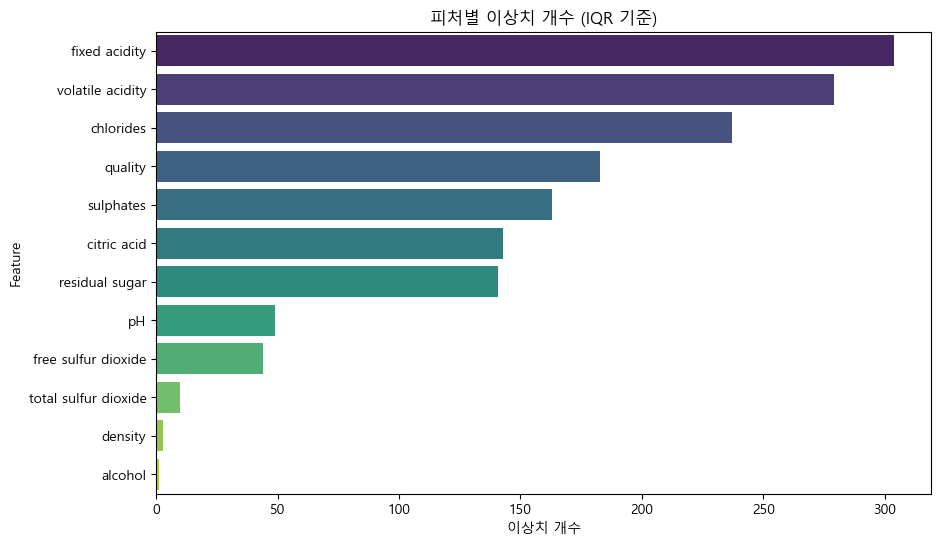

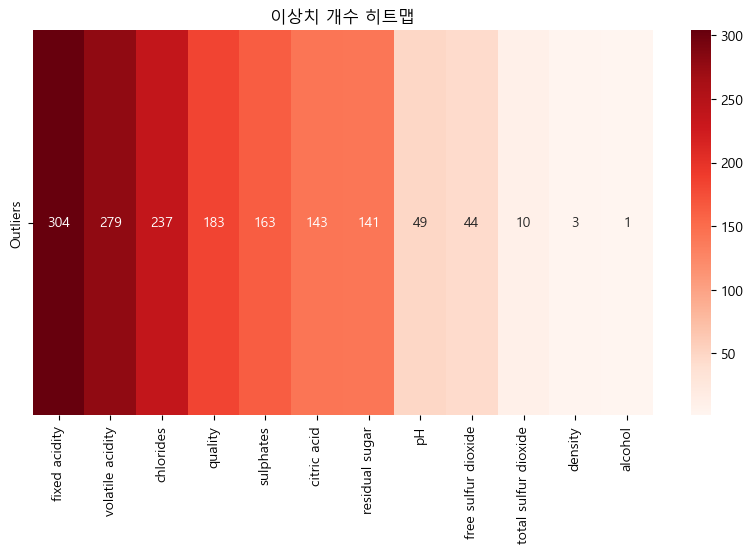

In [84]:
# [3-2] IQR 기반 이상치 개수 파악
import matplotlib.pyplot as plt
import seaborn as sns

# 이상치 개수 계산
outlier_counts = {}
for col in num_cols:
    q1, q3 = wineDF[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_counts[col] = ((wineDF[col] < lb) | (wineDF[col] > ub)).sum()

outlier_series = pd.Series(outlier_counts).sort_values(ascending=False)

# === 1. 막대그래프 ===
plt.figure(figsize=(10,6))
sns.barplot(x=outlier_series.values, y=outlier_series.index, palette="viridis")
plt.title("피처별 이상치 개수 (IQR 기준)")
plt.xlabel("이상치 개수")
plt.ylabel("Feature")
plt.show()

# === 2. 히트맵 (옵션) ===
plt.figure(figsize=(10,5))
sns.heatmap(outlier_series.values.reshape(1, -1), annot=True, fmt="d",
            cmap="Reds", xticklabels=outlier_series.index, yticklabels=["Outliers"])
plt.title("이상치 개수 히트맵")
plt.show()



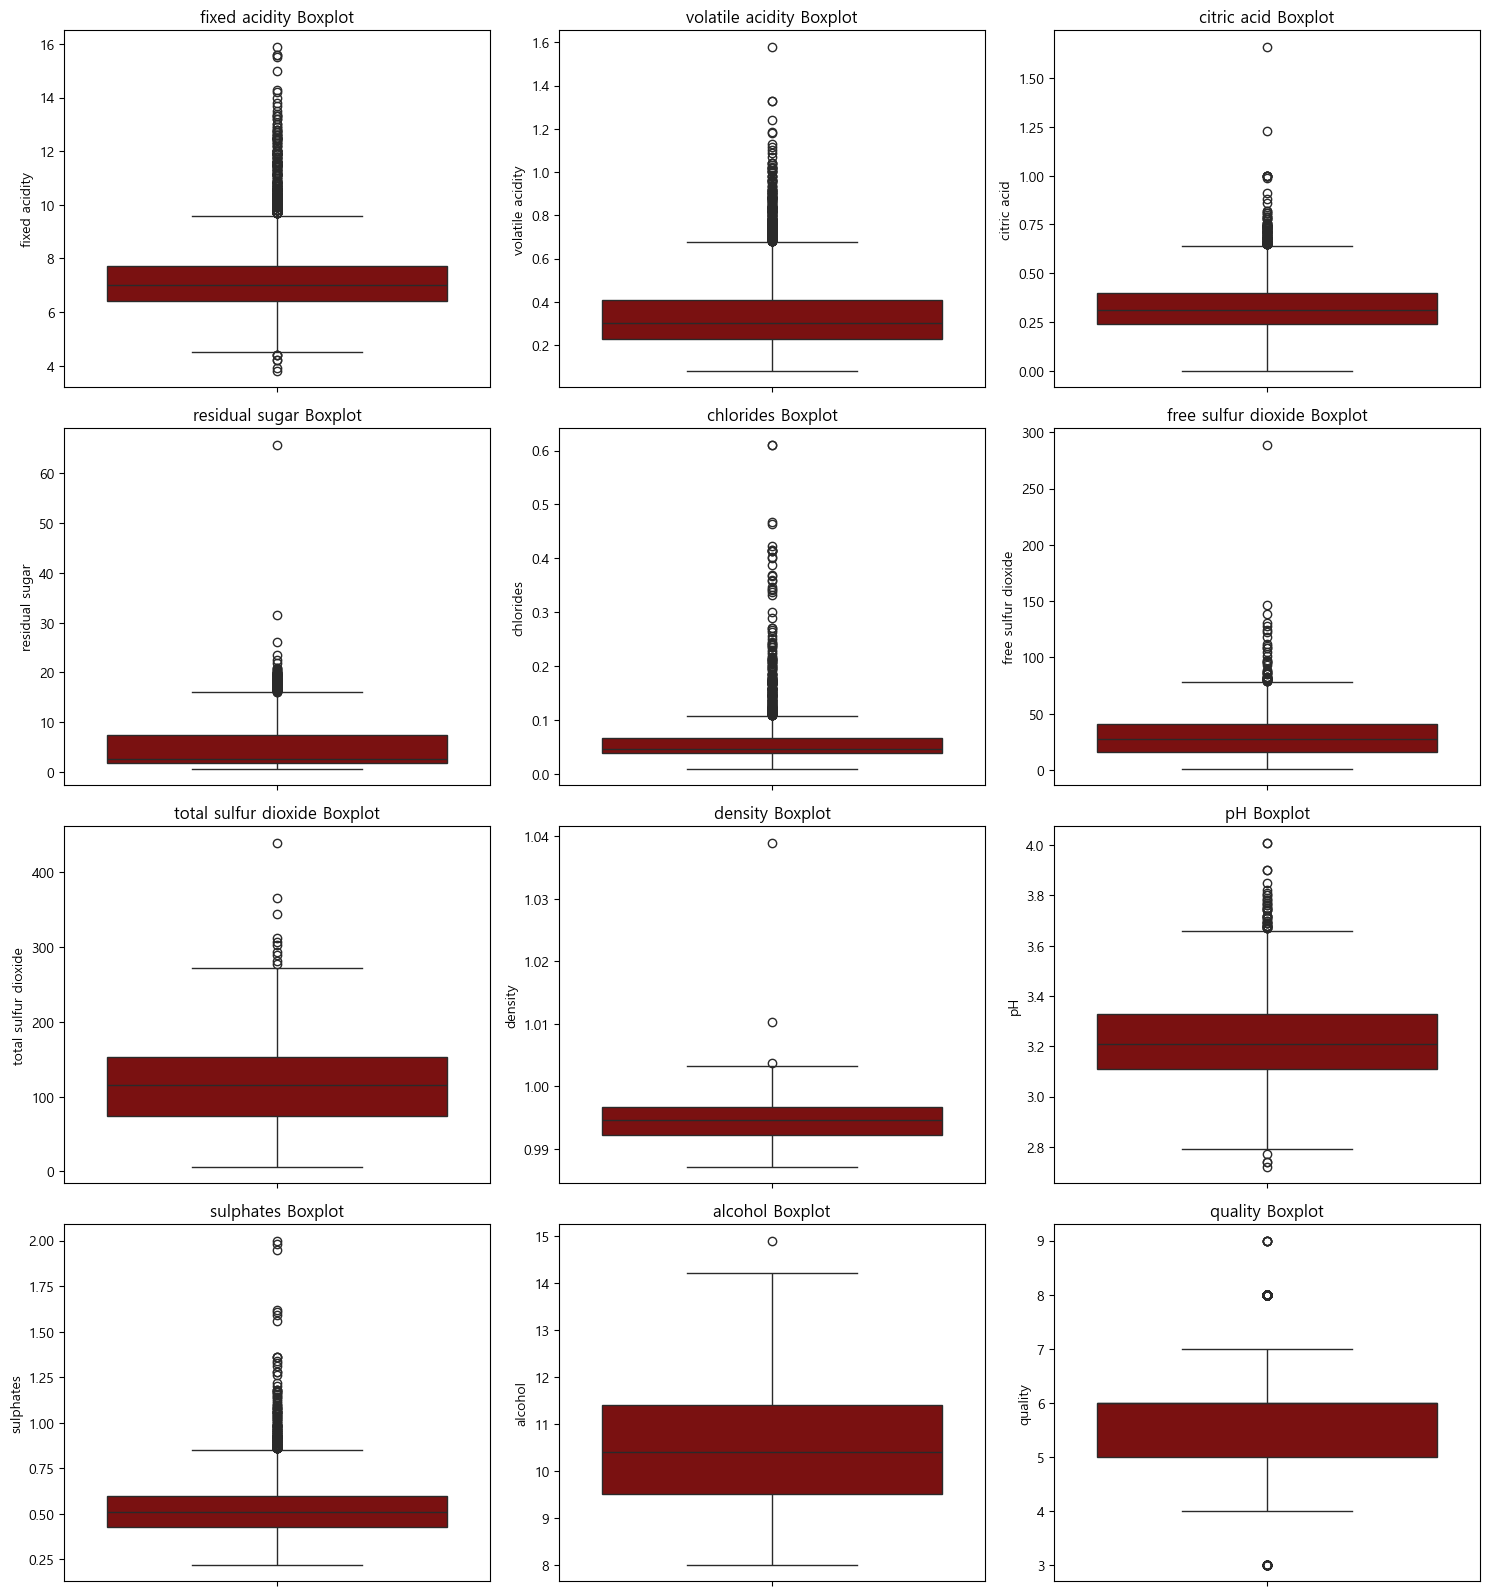

In [85]:
## 이상치 개수 확인
import matplotlib.pyplot as plt
import seaborn as sns

# 수치형 피처만 선택 (이미 num_cols 정의되어 있다면 그대로 사용 가능)
num_cols = featureDF.select_dtypes(include=['float64', 'int64']).columns

# 서브플롯 크기 설정
n_cols = 3
n_rows = int(len(num_cols) / n_cols) + 1

plt.figure(figsize=(15, n_rows*4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=featureDF[col], color="darkred")
    plt.title(f"{col} Boxplot")

plt.tight_layout()
plt.show()


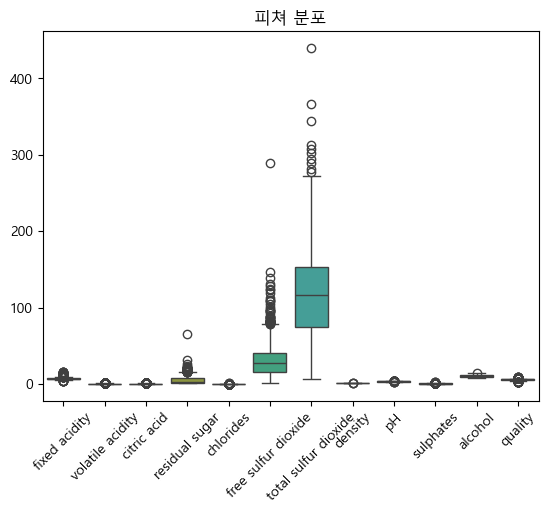

In [86]:
## 각 피쳐별 분포 확인(왜도/첨도)
## Boxplot
plt.Figure(figsize=(15,6))
sns.boxplot(data=featureDF)
plt.xticks(rotation=45)
plt.title('피쳐 분포')
plt.show()

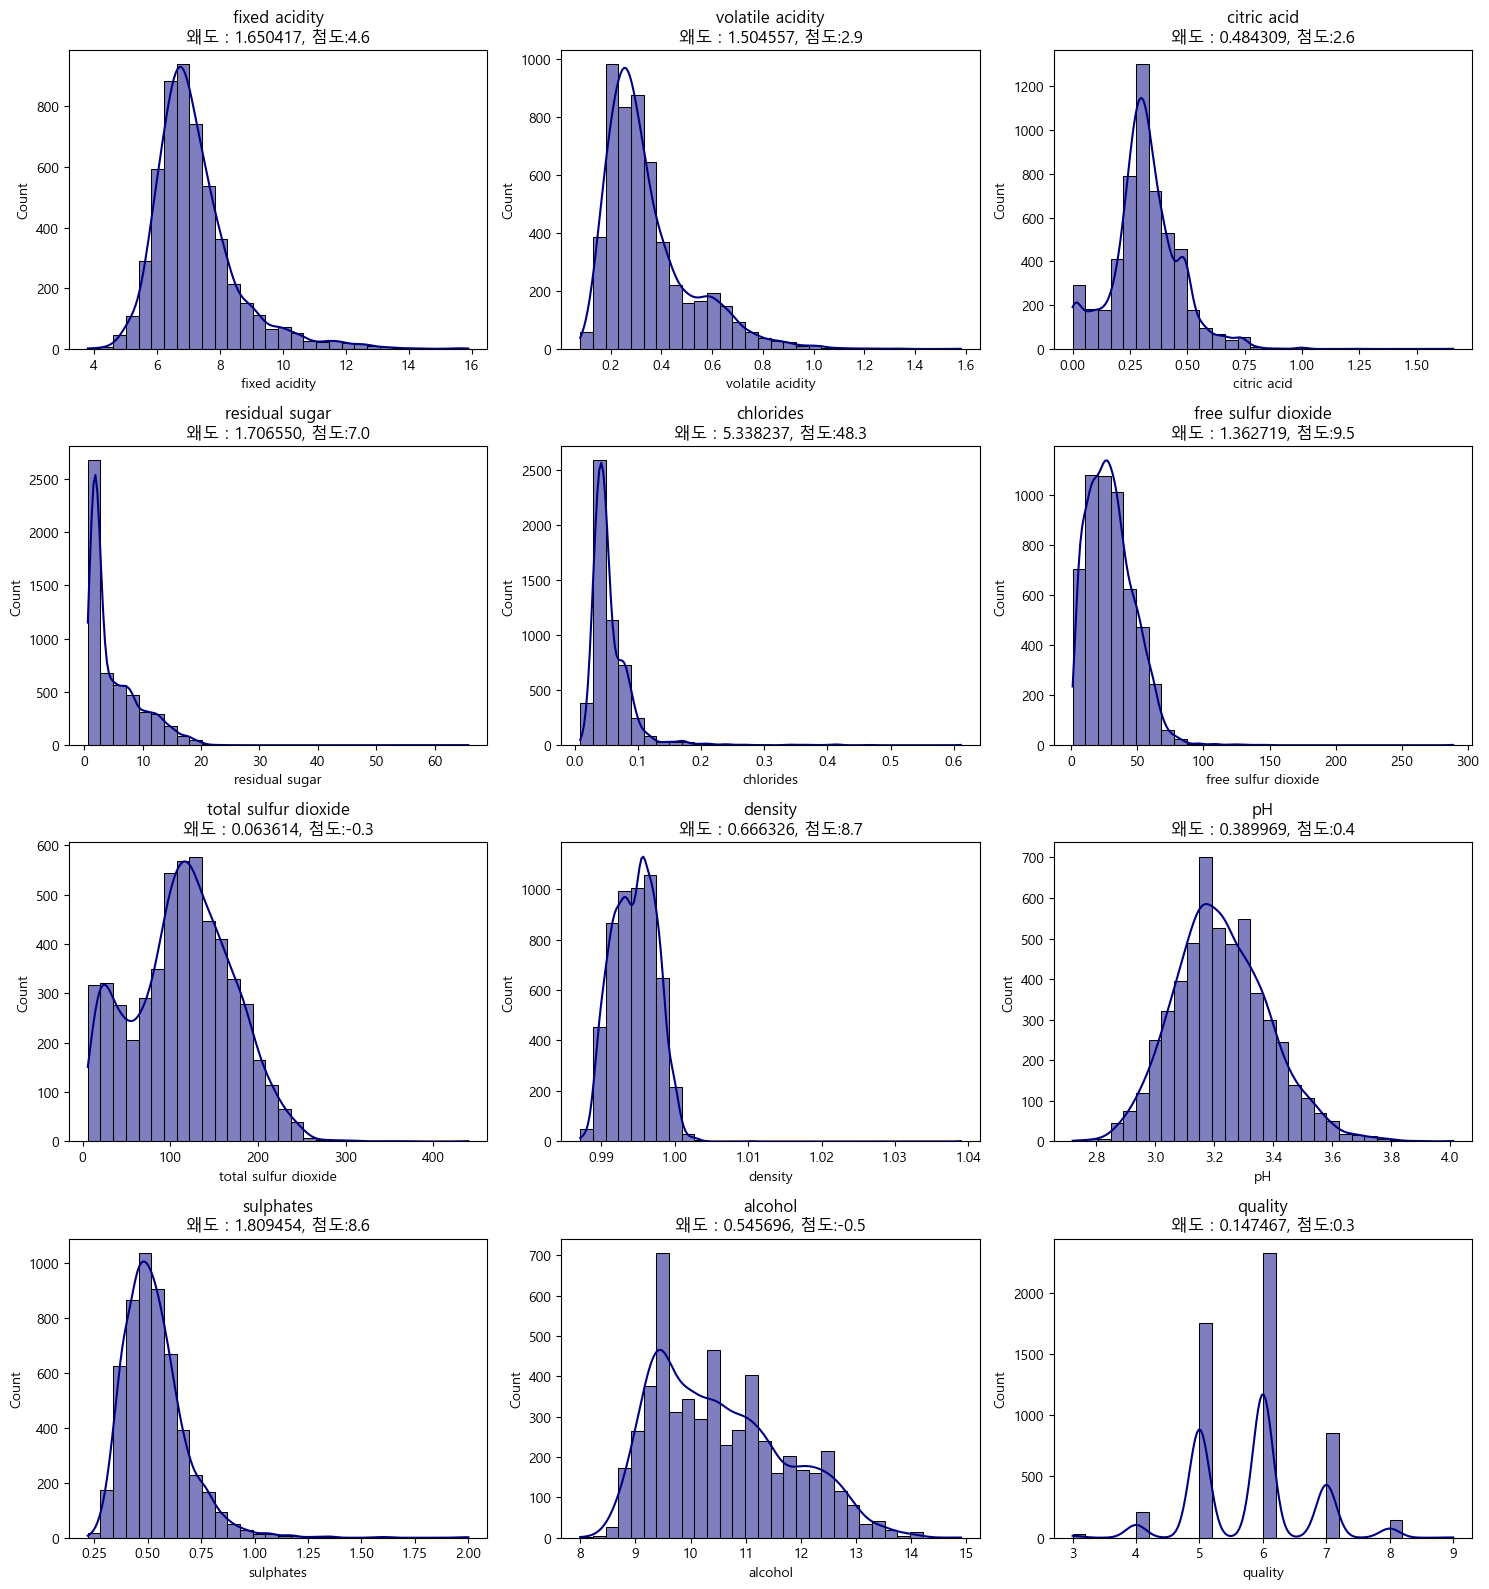

In [87]:
## Hisogram(각 피쳐별 분포 + 왜도/첨도)
n_cols = 3
n_rows = (len(featureDF.columns) + n_cols -1) // n_cols

plt.figure(figsize=(15, n_rows*4))
for i, col in enumerate(featureDF.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(featureDF[col], kde=True, bins=30, color='navy')
    skew=featureDF[col].skew()
    kurt=featureDF[col].kurt()
    plt.title(f'{col}\n왜도 : {skew:1f}, 첨도:{kurt:.1f}')

plt.tight_layout()
plt.show()

In [88]:
# 각 피쳐별 왜도 / 첨도 계산
skew_kurt = {}
for col in featureDF.columns:
    skew = featureDF[col].skew()
    kurt = featureDF[col].kurt()
    skew_kurt[col] = {"왜도(Skewness)": skew, "첨도(Kurtosis)": kurt}

# DataFrame으로 정리
skew_kurt_df = pd.DataFrame(skew_kurt).T
print(skew_kurt_df)


                      왜도(Skewness)  첨도(Kurtosis)
fixed acidity             1.650417      4.589079
volatile acidity          1.504557      2.863175
citric acid               0.484309      2.582471
residual sugar            1.706550      7.025595
chlorides                 5.338237     48.260708
free sulfur dioxide       1.362719      9.520706
total sulfur dioxide      0.063614     -0.299997
density                   0.666326      8.711498
pH                        0.389969      0.431811
sulphates                 1.809454      8.612917
alcohol                   0.545696     -0.538169
quality                   0.147467      0.298100


[4] 학습용/테스트용 데이터셋 준비<hr>
 - 학습용(trian) 데이터 기반 수치/범주

In [89]:
## [4-1] 피쳐/타겟 분류
# 피처/타겟 정의 (type_bin 제외)
X = wineDF.drop(columns=['type'], errors='ignore')
y = wineDF['type'].map({'red':0, 'white':1}).astype(int)

## 학습용/검증용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"[TRAIN] X:{X_train.shape}, y:{y_train.shape}")
print(f"[TEST ] X:{X_test.shape}, y:{y_test.shape}")

[TRAIN] X:(4256, 12), y:(4256,)
[TEST ] X:(1064, 12), y:(1064,)


In [90]:
# [4-2] 스케일링
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## 결측치 없음 : 생략
# imp = SimpleImputer(strategy='median')        # 결측값 대체 : 평균값
# X_train_imp = imp.fit_transform(X_train)
# X_test_imp  = imp.transform(X_test)

## train 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # 평균/표준편차 학습 + 변환
X_test_scaled  = scaler.transform(X_test)       # train 기준으로만 변환

[5] 학습 진행<hr>
 - [5-1] 기본 학습(L2 + lbfgs)
 - [5-2] Solver 간단 비교
 - [5-3] GridSearchCV 튜닝 -> 최적 모델 찾기
 - [5-4] score 선택 : 전체성능(accuracy), 확률분류품질/순위(roc_auc),  
                      불균형(f1, recall, precision)

In [91]:
## [5-1] 로지스틱 회귀 기본 학습(기본 : L2, lbfgs)
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    penalty='l2',            # 기본 : Ridge 규제
    solver = 'lbfgs',        # 안정적, 다중 클래스 지원
    max_iter=1000,
    class_weight=None        # 불균형 데이터면 'balanced'
)

## 학습
logit.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


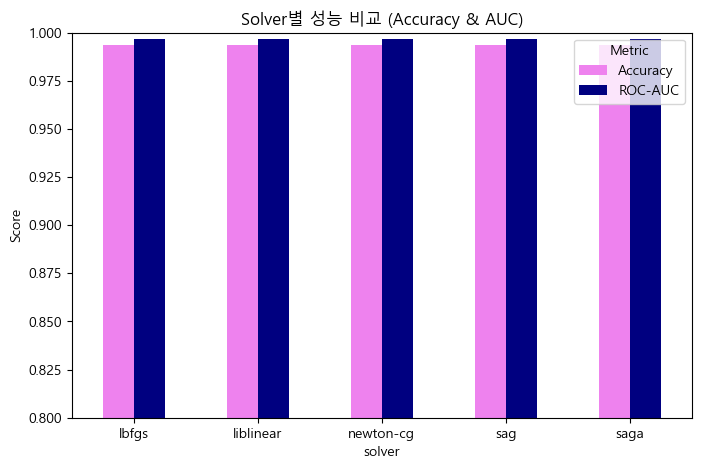

In [95]:
## [5-2] solver별 accuracy 비교
## solver : 데이터크기/희소성에 따라 수렴 안정성/속도 차이
## 여러개의 solver값 별로 LogisticRegression 학습 후 성능 평가
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression

# 결과 저장용 리스트
results = []
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']
for s in solvers:
    clf = LogisticRegression(solver=s, penalty='l2', max_iter=2000)
    clf.fit(X_train_scaled, y_train)
    p = clf.predict(X_test_scaled)
    pr = clf.predict_proba(X_test_scaled)[:, 1]
    results.append({
        "solver": s,
        "Accuracy": accuracy_score(y_test, p),
        "ROC-AUC": roc_auc_score(y_test, pr)
    })

# DataFrame 변환
df_results = pd.DataFrame(results)

# 시각화 (파란 계열 색상 적용)
ax = df_results.set_index("solver")[["Accuracy","ROC-AUC"]].plot(
    kind="bar", rot=0, figsize=(8,5),
    color=["violet","navy"]
)
plt.title("Solver별 성능 비교 (Accuracy & AUC)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.legend(title="Metric")
plt.show()



In [ ]:
## [5-3] GridSearchCV 튜닝(하이퍼파라미터 탐색)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = [
    {'solver': ['lbfgs', 'newton-cg', 'sag'], 'penalty': ['l2'],           'C': [0.01, 0.1, 1, 5, 10]},
    {'solver': ['liblinear'],                 'penalty': ['l1','l2'],      'C': [0.01, 0.1, 1, 5, 10]},
    {'solver': ['saga'],                      'penalty': ['l1','l2'],      'C': [0.01, 0.1, 1, 5, 10]},
]

grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid=param_grid,
    scoring='accuracy',   # 필요하면 'roc_auc'로 변경 가능
    cv=cv,
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print("최적 파라미터:", grid.best_params_)
print("CV 최적 평균 정확도:", f"{grid.best_score_:.4f}")

# 최적 모델로 교체
best_clf = grid.best_estimator_


최적 파라미터: {'C': 5, 'penalty': 'l2', 'solver': 'newton-cg'}
CV 최적 평균 정확도: 0.9930


In [ ]:
# ## [5-1] 로지스틱 회귀모델 정의 및  : 단일모델
# from sklearn.linear_model import LogisticRegression

# logit = LogisticRegression(
#     penalty='l2',       # 기본 L2 규제
#     solver='lbfgs',     # 안정적/빠름, 이진/다중
#     max_iter=1000,
#     class_weight=None   # 불균형이면 'balanced'로 바꾸기

# logit.fit(X_train_scaled, y_train)

# GridSearchCV는 내부에서 이렇게 돌아갑니다:
# 지정한 LogisticRegression() 객체를 가져옴 (base_lr = LogisticRegression(...))
# param_grid에 따라 여러 하이퍼파라미터 조합을 바꿔가며 .fit() 실행
# 교차검증 결과를 비교해서 최적 조합을 선택
# best_estimator_로 최종 모델을 이미 학습(fit)한 상태로 반환

In [ ]:
# ## [5-2] GridSearchCV (AUC 기준)
# ## GridSearchCV (최적 하이퍼파라미터 탐색)
# ## 호환 규칙:
# ## - lbfgs/newton-cg/sag : penalty='l2'만 가능
# from sklearn.model_selection import GridSearchCV, StratifiedKFold

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# param_grid = [
#     {'solver': ['lbfgs', 'newton-cg', 'sag'], 'penalty': ['l2'], 'C': [0.01, 0.1, 1, 5, 10]},
#     {'solver': ['liblinear'], 'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 5, 10]},
#     {'solver': ['saga'], 'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 5, 10]}
# ]

# ## 다중 스코어링으로 그리드서치 (AUC 기준으로 최종 선택)
# ## 여러 지표를 계산하고, 최종 refit은 AUC가 가장 높은 모델로 선택
# base_lr = LogisticRegression(max_iter=5000)
# grid = GridSearchCV(
#     LogisticRegression(max_iter=5000),
#     param_grid=param_grid,
#     scoring='roc_auc',
#     cv=cv,
#     n_jobs=-1
# )
# grid.fit(X_train_scaled, y_train)

# print("Best Params:", grid.best_params_)
# print("CV Best AUC:", grid.best_score_)

# # 최종 사용할 분류기 선택 (튜닝 사용 시 best_estimator_, 아니면 기본 모델)
# clf = grid.best_estimator_ if hasattr(grid, "best_estimator_") else logit


[6] 학습 평가 <hr>

In [98]:
## [6-1] 최적 모델 성능 확인
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

y_pred_best  = best_clf.predict(X_test_scaled)
y_proba_best = best_clf.predict_proba(X_test_scaled)[:, 1]

print(f"[Best] Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"[Best] Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"[Best] Recall   : {recall_score(y_test, y_pred_best):.4f}")
print(f"[Best] F1-score : {f1_score(y_test, y_pred_best):.4f}")
print(f"[Best] ROC-AUC  : {roc_auc_score(y_test, y_proba_best):.4f}")

print("\n[Classification Report]\n",
      classification_report(y_test, y_pred_best, target_names=['red(0)','white(1)'], digits=4))
print("[Confusion Matrix]\n", confusion_matrix(y_test, y_pred_best))


[Best] Accuracy : 0.9944
[Best] Precision: 0.9950
[Best] Recall   : 0.9975
[Best] F1-score : 0.9962
[Best] ROC-AUC  : 0.9965

[Classification Report]
               precision    recall  f1-score   support

      red(0)     0.9926    0.9853    0.9889       272
    white(1)     0.9950    0.9975    0.9962       792

    accuracy                         0.9944      1064
   macro avg     0.9938    0.9914    0.9926      1064
weighted avg     0.9944    0.9944    0.9944      1064

[Confusion Matrix]
 [[268   4]
 [  2 790]]


C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_27240\405619696.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="Blues_d")


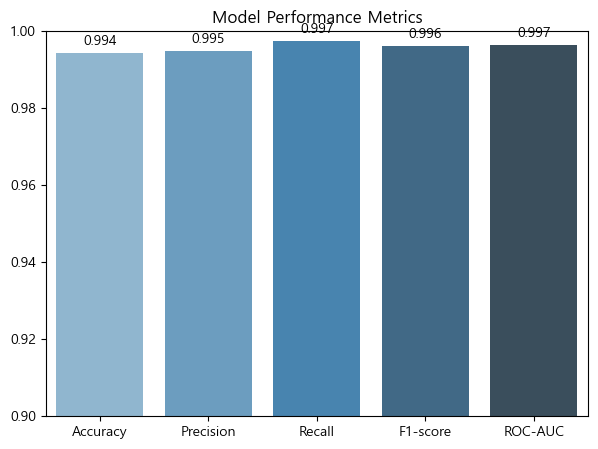

In [99]:
import numpy as np

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best),
    "Recall": recall_score(y_test, y_pred_best),
    "F1-score": f1_score(y_test, y_pred_best),
    "ROC-AUC": roc_auc_score(y_test, y_proba_best)
}

plt.figure(figsize=(7,5))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="Blues_d")
plt.ylim(0.9, 1.0)  # 성능이 높은 모델이니 보기 좋게 축 제한
plt.title("Model Performance Metrics")
for i, v in enumerate(metrics.values()):
    plt.text(i, v+0.002, f"{v:.3f}", ha='center')
plt.show()


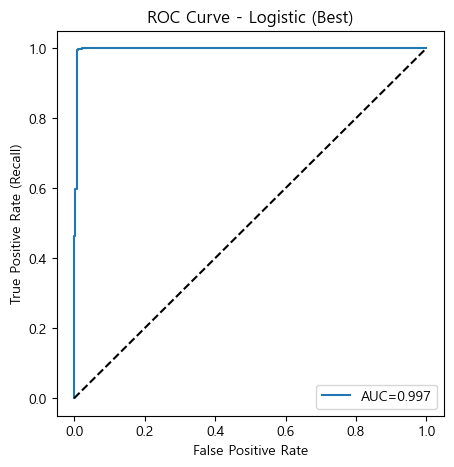

In [ ]:
## [6-2] ROC 곡선
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thr = roc_curve(y_test, y_proba_best)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, y_proba_best):.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic (Best)"); plt.legend(); plt.show()

[7] 예측 <hr>

In [100]:
## [7-1] 원본 데이터 X에서 샘플 5개 뽑기 -> 예측
sample_df = X.sample(5, random_state=42)
sample_sc  = scaler.transform(sample_df)

sample_pred  = best_clf.predict(sample_sc)
sample_proba = best_clf.predict_proba(sample_sc)

print("\n=== 샘플 데이터 예측 결과 ===")
for i, idx in enumerate(sample_df.index):
    print(f"\nRow {idx}:")
    print("입력 피처:", sample_df.iloc[i].to_dict())
    print("예측 type:", "white(1)" if sample_pred[i]==1 else "red(0)")
    print("클래스별 확률:", dict(zip(best_clf.classes_, sample_proba[i])))



=== 샘플 데이터 예측 결과 ===

Row 2221:
입력 피처: {'fixed acidity': 5.3, 'volatile acidity': 0.32, 'citric acid': 0.12, 'residual sugar': 6.6, 'chlorides': 0.043, 'free sulfur dioxide': 22.0, 'total sulfur dioxide': 141.0, 'density': 0.9937, 'pH': 3.36, 'sulphates': 0.6, 'alcohol': 10.4, 'quality': 6.0}
예측 type: white(1)
클래스별 확률: {0: 0.00031253552352772385, 1: 0.9996874644764723}

Row 6167:
입력 피처: {'fixed acidity': 6.4, 'volatile acidity': 0.3, 'citric acid': 0.27, 'residual sugar': 4.4, 'chlorides': 0.055, 'free sulfur dioxide': 17.0, 'total sulfur dioxide': 135.0, 'density': 0.9925, 'pH': 3.23, 'sulphates': 0.44, 'alcohol': 12.2, 'quality': 6.0}
예측 type: white(1)
클래스별 확률: {0: 0.0016008474172003462, 1: 0.9983991525827997}

Row 4500:
입력 피처: {'fixed acidity': 6.5, 'volatile acidity': 0.22, 'citric acid': 0.32, 'residual sugar': 2.2, 'chlorides': 0.028, 'free sulfur dioxide': 36.0, 'total sulfur dioxide': 92.0, 'density': 0.99076, 'pH': 3.27, 'sulphates': 0.59, 'alcohol': 11.9, 'quality': 7.0}
예측 

   index   예측 type  red(0) 확률  white(1) 확률
0   2221  white(1)   0.000313     0.999687
1   6167  white(1)   0.001601     0.998399
2   4500  white(1)   0.009352     0.990648
3   5051  white(1)   0.001668     0.998332
4    639    red(0)   0.999499     0.000501


C:\Users\KDT-57-\AppData\Local\Temp\ipykernel_27240\3413300197.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="index", y="예측 type", data=sample_results, ax=axes[0], palette=palette)


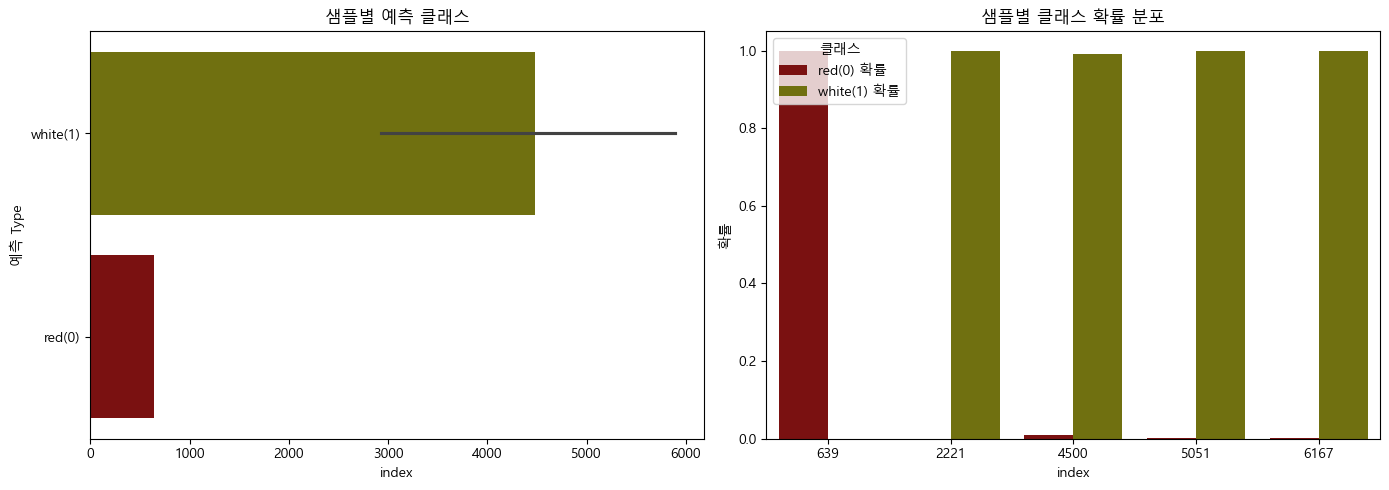

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 샘플 데이터 예측 (이미 구한 sample_df, sample_pred, sample_proba 활용)
sample_results = pd.DataFrame({
    "index": sample_df.index,
    "예측 type": ["white(1)" if p==1 else "red(0)" for p in sample_pred],
    "red(0) 확률": sample_proba[:,0],
    "white(1) 확률": sample_proba[:,1]
})

print(sample_results)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# (1) 예측 클래스 막대그래프 (red=darkred, white=olive)
palette = {"red(0)": "darkred", "white(1)": "olive"}
sns.barplot(x="index", y="예측 type", data=sample_results, ax=axes[0], palette=palette)
axes[0].set_title("샘플별 예측 클래스")
axes[0].set_ylabel("예측 Type")

# (2) 확률 분포 시각화 (red=darkred, white=olive)
sample_results_melt = sample_results.melt(id_vars=["index","예측 type"], 
                                          value_vars=["red(0) 확률","white(1) 확률"],
                                          var_name="클래스", value_name="확률")

palette_probs = {"red(0) 확률": "darkred", "white(1) 확률": "olive"}
sns.barplot(x="index", y="확률", hue="클래스", data=sample_results_melt, 
            ax=axes[1], palette=palette_probs)
axes[1].set_title("샘플별 클래스 확률 분포")

plt.tight_layout()
plt.show()


[8] 최종결과 요약 <hr>

In [ ]:
## [8-1] 핵심 성능 요약
summary = {
    "Accuracy":  accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best),
    "Recall":    recall_score(y_test, y_pred_best),
    "F1":        f1_score(y_test, y_pred_best),
    "ROC_AUC":   roc_auc_score(y_test, y_proba_best)
}
print(pd.Series(summary).round(4))

Accuracy     0.9944
Precision    0.9950
Recall       0.9975
F1           0.9962
ROC_AUC      0.9965
dtype: float64



[상위 중요 피처]


,feature,coef,abs_coef
7,density,-4.129281,4.129281
3,residual sugar,3.789250,3.789250
6,total sulfur dioxide,2.739474,2.739474
10,alcohol,-1.466064,1.466064
1,volatile acidity,-1.197467,1.197467
5,free sulfur dioxide,-0.903582,0.903582
4,chlorides,-0.886177,0.886177
9,sulphates,-0.587122,0.587122
11,quality,-0.295631,0.295631
2,citric acid,0.264459,0.264459


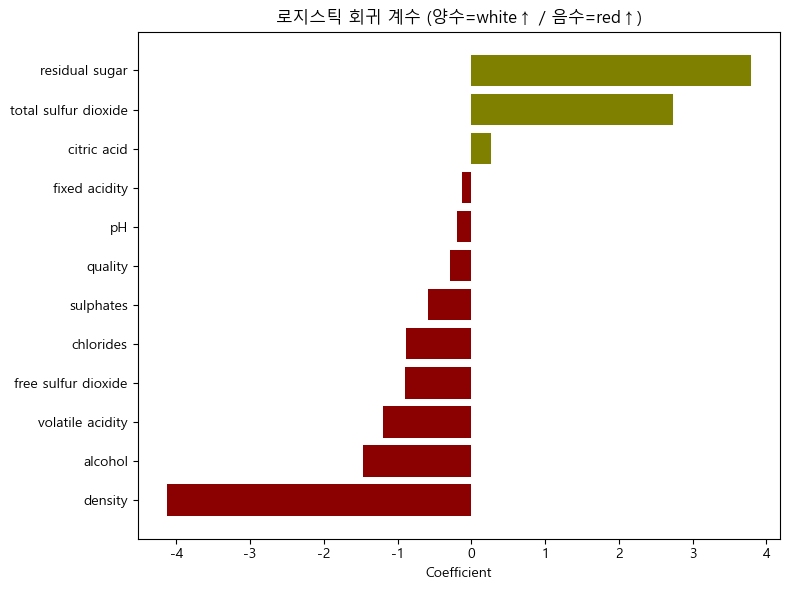

In [118]:
## [8-2] 피쳐 중요도(계수) 요약 및 시각화
# 계수(중요 피처) 정리/시각화
coef = best_clf.coef_.ravel()
imp_df = pd.DataFrame({
    'feature': X.columns,
    'coef': coef,
    'abs_coef': np.abs(coef)
}).sort_values('abs_coef', ascending=False)

print("\n[상위 중요 피처]")
display(imp_df.head(10))

# 부호: 양수=white↑(olive), 음수=red↑(darkred)
imp_sorted = imp_df.sort_values('coef')
colors = ['darkred' if c < 0 else 'olive' for c in imp_sorted['coef']]

plt.figure(figsize=(8,6))
plt.barh(imp_sorted['feature'], imp_sorted['coef'], color=colors)
plt.title("로지스틱 회귀 계수 (양수=white↑ / 음수=red↑)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()


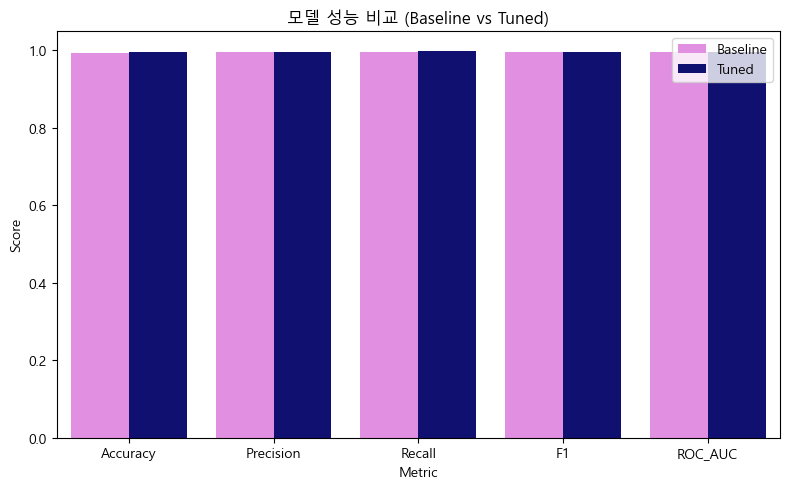

,Metric,Baseline,Tuned
0,Accuracy,0.9934,0.9944
1,Precision,0.9950,0.9950
2,Recall,0.9962,0.9975
3,F1,0.9956,0.9962
4,ROC_AUC,0.9966,0.9965


In [ ]:
## [8-3] 튜닝 전후 모델 성능 비교
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 예측
y_pred_base  = logit.predict(X_test_scaled)
y_proba_base = logit.predict_proba(X_test_scaled)[:, 1]
y_pred_best  = best_clf.predict(X_test_scaled)
y_proba_best = best_clf.predict_proba(X_test_scaled)[:, 1]

def metric_dict(y_true, y_pred, y_proba):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "ROC_AUC":   roc_auc_score(y_true, y_proba),
    }

base_scores = metric_dict(y_test, y_pred_base, y_proba_base)
best_scores = metric_dict(y_test, y_pred_best, y_proba_best)

cmp_df = pd.DataFrame({
    "Metric": list(base_scores.keys()),
    "Baseline": list(base_scores.values()),
    "Tuned": list(best_scores.values())
})

plt.figure(figsize=(8,5))
melted = cmp_df.melt(id_vars="Metric", var_name="Model", value_name="Score")

# 색상 변경 (violet, navy)
sns.barplot(data=melted, x="Metric", y="Score", hue="Model", palette=["violet","navy"])

plt.ylim(0, 1.05)
plt.title("모델 성능 비교 (Baseline vs Tuned)")
plt.legend(title="")
plt.tight_layout()
plt.show()

display(cmp_df.round(4))




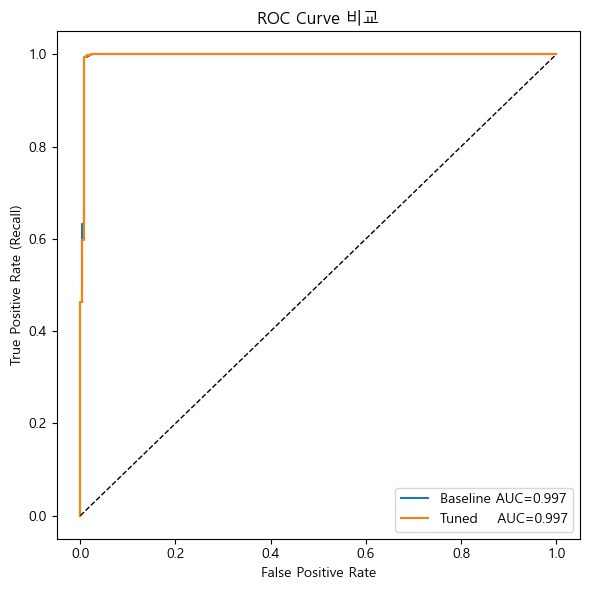

In [ ]:
## [8-4] ROC 곡선 비교
from sklearn.metrics import roc_curve

fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_base)
fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_best)

plt.figure(figsize=(6,6))
plt.plot(fpr_b, tpr_b, label=f"Baseline AUC={roc_auc_score(y_test, y_proba_base):.3f}")
plt.plot(fpr_t, tpr_t, label=f"Tuned    AUC={roc_auc_score(y_test, y_proba_best):.3f}")
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve 비교")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## [8-4] 임계값 최적화(F1) 전후 비교
from sklearn.metrics import f1_score

def best_threshold_by_f1(y_true, y_proba):
    best_thr, best_f1 = 0.5, 0
    for thr in np.linspace(0.1, 0.9, 81):
        f1 = f1_score(y_true, (y_proba >= thr).astype(int))
        if f1 > best_f1:
            best_thr, best_f1 = thr, f1
    return best_thr, best_f1

thr_b, f1_b = best_threshold_by_f1(y_test, y_proba_base)
thr_t, f1_t = best_threshold_by_f1(y_test, y_proba_best)

print(f"[Baseline] Best thr={thr_b:.2f}, F1={f1_b:.4f}")
print(f"[Tuned   ] Best thr={thr_t:.2f}, F1={f1_t:.4f}")

[Baseline] Best thr=0.19, F1=0.9962
[Tuned   ] Best thr=0.35, F1=0.9968


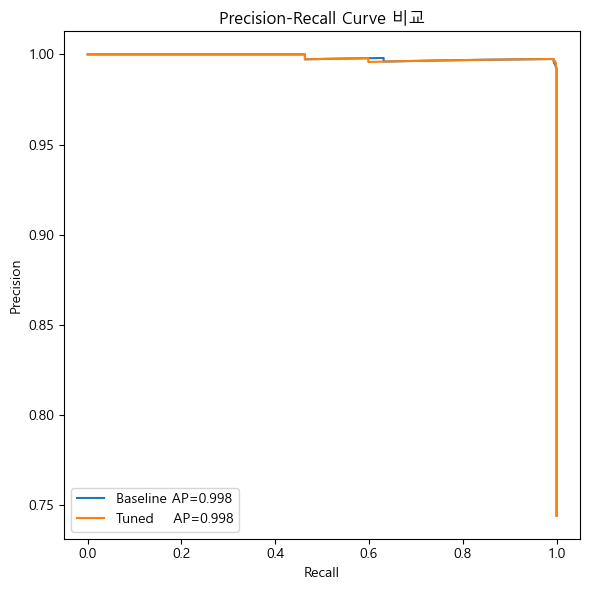

In [ ]:
## [8-5] PR(정밀도-재현율) 곡선 비교
from sklearn.metrics import precision_recall_curve, average_precision_score

p_b, r_b, _ = precision_recall_curve(y_test, y_proba_base)
p_t, r_t, _ = precision_recall_curve(y_test, y_proba_best)

ap_b = average_precision_score(y_test, y_proba_base)
ap_t = average_precision_score(y_test, y_proba_best)

plt.figure(figsize=(6,6))
plt.plot(r_b, p_b, label=f"Baseline AP={ap_b:.3f}")
plt.plot(r_t, p_t, label=f"Tuned    AP={ap_t:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve 비교")
plt.legend()
plt.tight_layout()
plt.show()


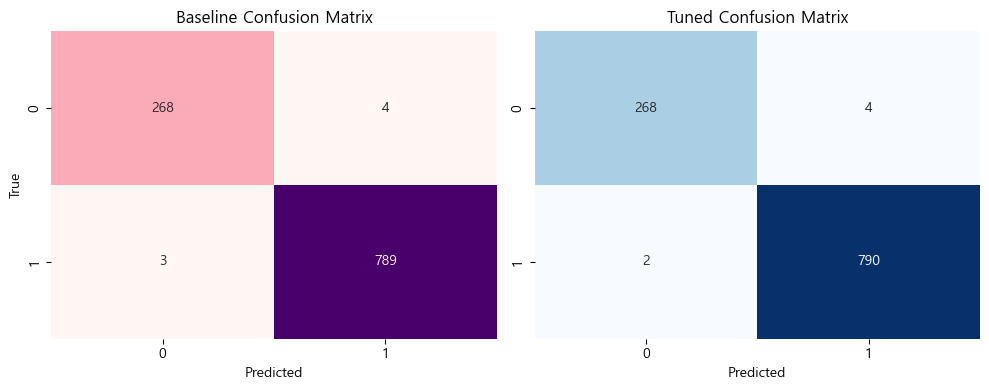

In [112]:
## [8-5] 혼동행렬 전후 비교(정확도 체감용)
from sklearn.metrics import confusion_matrix

from sklearn.metrics import confusion_matrix

cm_base = confusion_matrix(y_test, y_pred_base)
cm_best = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Baseline → 핑크 계열
sns.heatmap(cm_base, annot=True, fmt="d", cmap="RdPu", cbar=False, ax=axes[0])
axes[0].set_title("Baseline Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

# Tuned → 파란 계열
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Tuned Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("")

plt.tight_layout()
plt.show()



In [107]:
## [8-6] 계수 비교
import pandas as pd
import numpy as np

coef_base = pd.Series(logit.coef_.ravel(), index=X.columns, name="Baseline")
coef_best = pd.Series(best_clf.coef_.ravel(), index=X.columns, name="Tuned")
coef_cmp = pd.concat([coef_base, coef_best], axis=1)
coef_cmp["abs_diff"] = (coef_cmp["Tuned"] - coef_cmp["Baseline"]).abs()
coef_cmp.sort_values("abs_diff", ascending=False).head(10)

,Baseline,Tuned,abs_diff
density,-3.200592,-4.129281,0.928688
residual sugar,3.010660,3.789250,0.778591
alcohol,-1.029579,-1.466064,0.436485
fixed acidity,-0.450801,-0.130536,0.320265
pH,-0.435842,-0.196056,0.239786
free sulfur dioxide,-0.693180,-0.903582,0.210403
total sulfur dioxide,2.595647,2.739474,0.143827
sulphates,-0.687585,-0.587122,0.100462
quality,-0.259700,-0.295631,0.035931
volatile acidity,-1.232187,-1.197467,0.034720


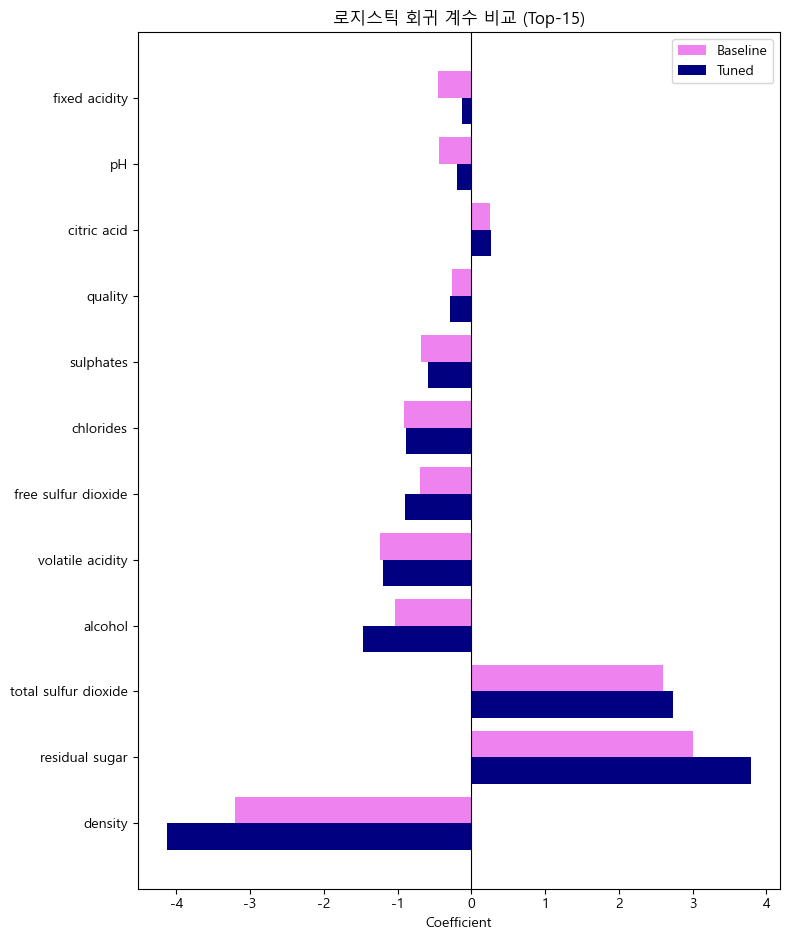

In [116]:
## 튜닝 모델 기준 중요 피쳐 
import numpy as np
import pandas as pd

# coef_best가 numpy 배열이라면 DataFrame으로 변환
coef_best_df = pd.Series(coef_best.ravel(), index=X.columns, name="coef")

# 절댓값 기준 상위 N개 피쳐 선택
top_feats = coef_cmp.reindex(coef_best_df.abs().sort_values(ascending=False).head(N).index)

# 시각화
plt.figure(figsize=(8, 0.5*N + 2))
y = np.arange(len(top_feats))
bar_w = 0.4

plt.barh(y + bar_w/2, top_feats["Baseline"], height=bar_w, 
         label="Baseline", color="violet")
plt.barh(y - bar_w/2, top_feats["Tuned"],    height=bar_w, 
         label="Tuned", color="navy")

plt.yticks(y, top_feats.index)
plt.axvline(0, color="k", linewidth=0.8)
plt.title(f"로지스틱 회귀 계수 비교 (Top-{N})")
plt.xlabel("Coefficient")
plt.legend()
plt.tight_layout()
plt.show()



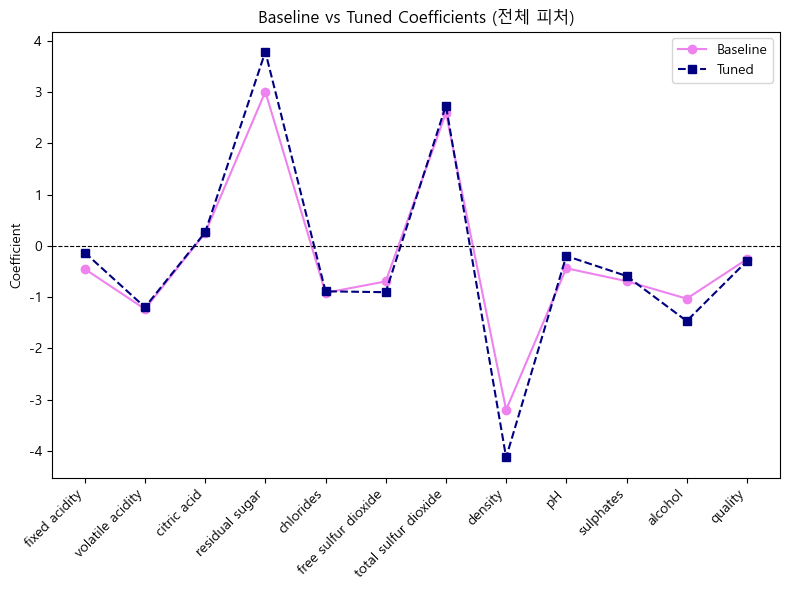

In [117]:
import matplotlib.pyplot as plt

coef_base = logit.coef_.ravel()
coef_best = best_clf.coef_.ravel()

plt.figure(figsize=(8,6))
plt.plot(coef_base, 'o-', color="violet", label="Baseline")
plt.plot(coef_best, 's--', color="navy", label="Tuned")
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)

plt.xticks(range(len(X.columns)), X.columns, rotation=45, ha='right')
plt.ylabel("Coefficient")
plt.title("Baseline vs Tuned Coefficients (전체 피처)")
plt.legend()
plt.tight_layout()
plt.show()


[9] 모델 저장 <hr>

In [110]:
## [9-1] 모델 저장
import joblib

# GridSearchCV 최적 모델(best_clf) 저장
joblib.dump(best_clf, "logistic_wine_best.pkl")

# 스케일러도 같이 저장해야 동일 전처리 가능
joblib.dump(scaler, "wine_scaler.pkl")

print("모델 및 스케일러 저장 완료")


모델 및 스케일러 저장 완료


In [111]:
## [9-2] 모델 활용
# 저장된 파일 로드
loaded_clf = joblib.load("logistic_wine_best.pkl")
loaded_scaler = joblib.load("wine_scaler.pkl")

# 새로운 데이터 예측 테스트
sample_df = X.sample(3, random_state=99)
sample_sc = loaded_scaler.transform(sample_df)
preds = loaded_clf.predict(sample_sc)
proba = loaded_clf.predict_proba(sample_sc)

print("=== 저장된 모델 예측 ===")
for i, idx in enumerate(sample_df.index):
    print(f"Row {idx} → Pred:{preds[i]}, Prob:{proba[i]}")


=== 저장된 모델 예측 ===
Row 3756 → Pred:1, Prob:[0.0025009 0.9974991]
Row 6495 → Pred:1, Prob:[4.83410034e-04 9.99516590e-01]
Row 2936 → Pred:1, Prob:[6.46685222e-06 9.99993533e-01]
